In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("owid-energy-data.csv")

In [9]:
# The current dataset 'owid-energy-data.csv' does not contain 'alert' and 'magnitude' columns
# which are required for the subsequent plotting code (resulting in KeyError).
# To allow the plotting code to execute, dummy 'alert' and 'magnitude' columns have been added.
# Please replace "owid-energy-data.csv" with the path to the correct dataset if needed,
# or modify how 'alert' and 'magnitude' are derived from your actual data.
df = pd.read_csv("owid-energy-data.csv")

# Add dummy 'alert' and 'magnitude' columns for demonstration purposes
np.random.seed(42) # for reproducibility
alert_levels = ['green', 'yellow', 'orange', 'red']
df['alert'] = np.random.choice(alert_levels, size=len(df))
df['magnitude'] = np.random.uniform(low=0.0, high=10.0, size=len(df))

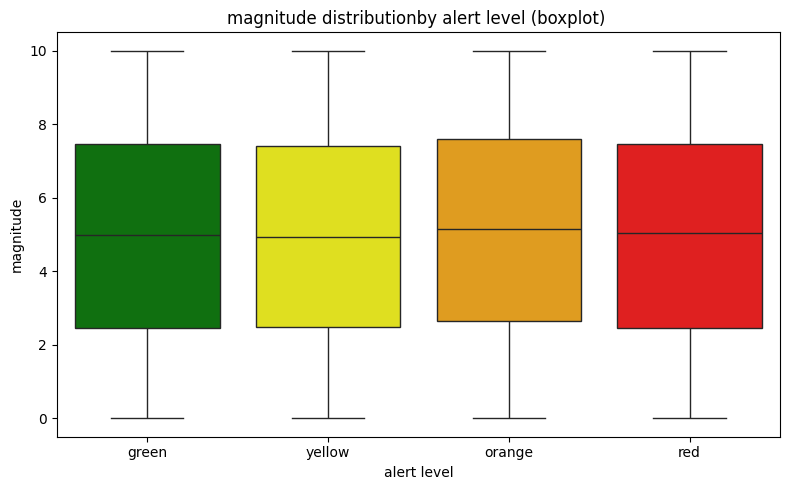

In [10]:
alert_order = ['green', 'yellow', 'orange', 'red']
alert_colors = {'green': 'green', 'yellow': 'yellow', 'orange': 'orange', 'red': 'red'}
plt.figure(figsize=(8,5))
sns.boxplot(data=df[df['alert'] != 'unknown'],x='alert', y='magnitude', hue='alert', order =alert_order, palette=alert_colors)
plt.title('magnitude distributionby alert level (boxplot) ')
plt.xlabel('alert level')
plt.ylabel('magnitude')
plt.tight_layout()
plt.show()

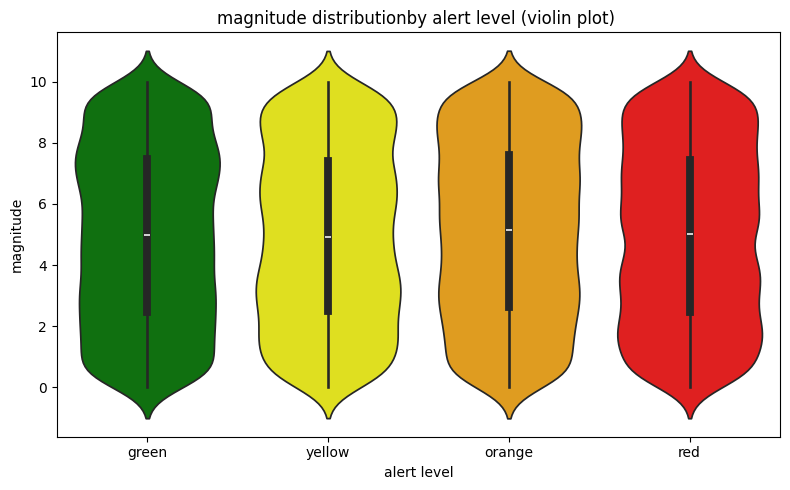

In [11]:
alert_order = ['green', 'yellow', 'orange', 'red']
alert_colors = {'green': 'green', 'yellow': 'yellow', 'orange': 'orange', 'red': 'red'}
plt.figure(figsize=(8,5))
sns.violinplot(data=df[df['alert'] != 'unknown'],x='alert', y='magnitude', hue='alert', order =alert_order, palette=alert_colors)
plt.title('magnitude distributionby alert level (violin plot) ')
plt.xlabel('alert level')
plt.ylabel('magnitude')
plt.tight_layout()
plt.show()

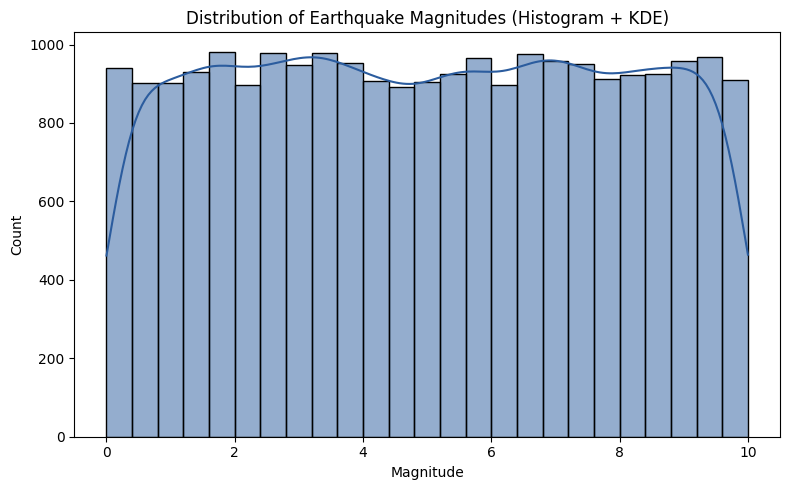

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='magnitude', kde=True, bins=25, color='#2b5c9e')
plt.title ('Distribution of Earthquake Magnitudes (Histogram + KDE)')

plt.xlabel('Magnitude')

plt.ylabel('Count')

plt.tight_layout()

plt.show()

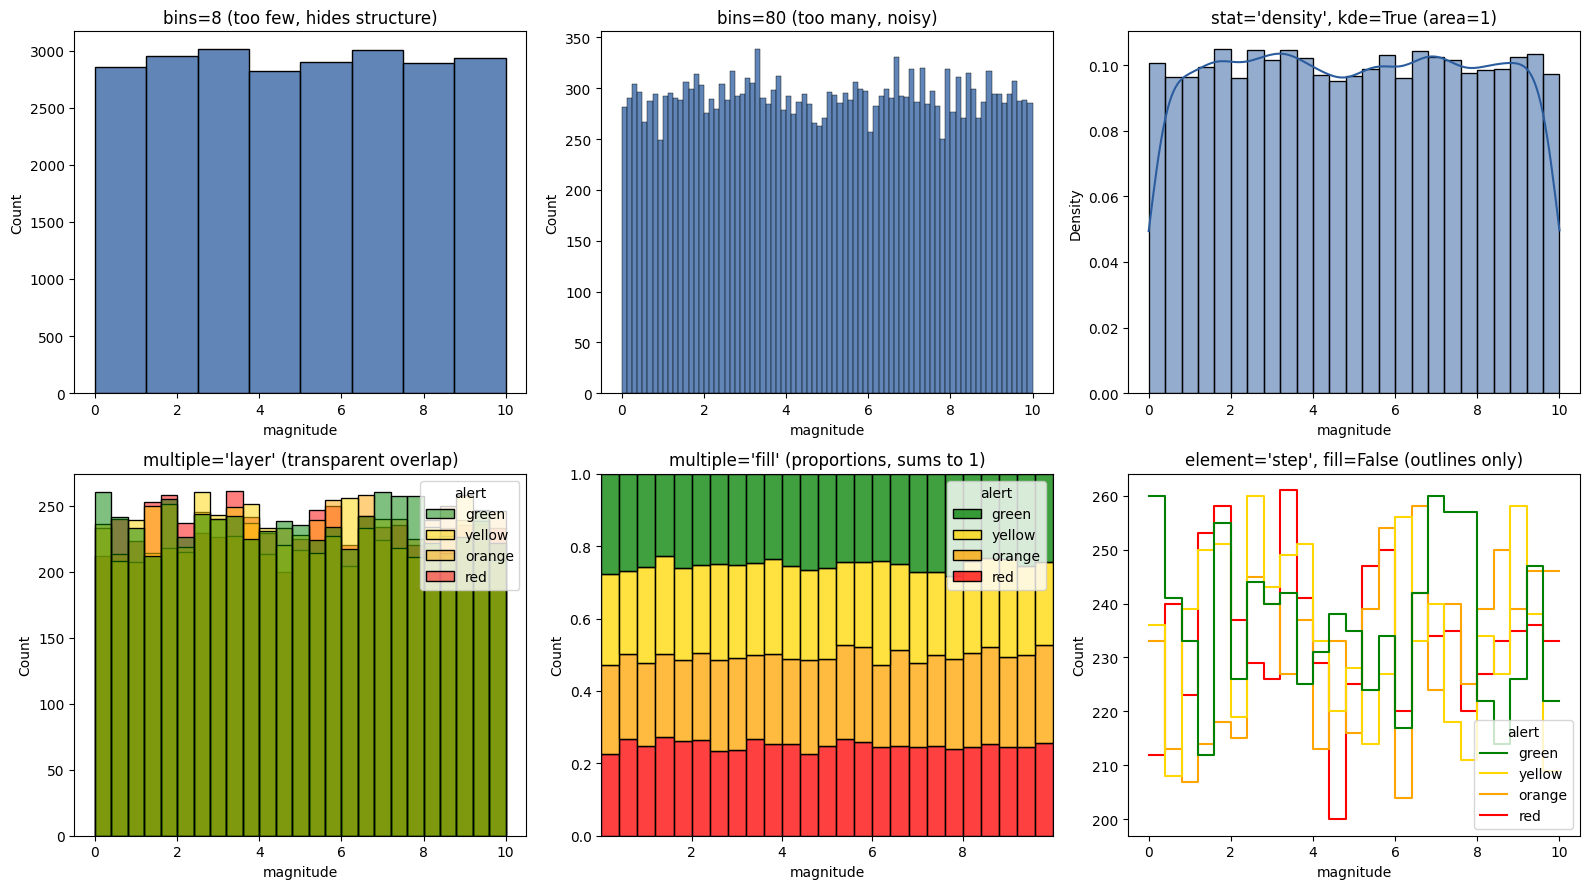

In [13]:
order = ['green', 'yellow', 'orange', 'red']

pal = ['green', 'gold', 'orange', 'red']

d = df[df['alert'] != 'unknown']

# 2 rows x 3 columns of axes; ax is a 2D array you index as ax[row, col]

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# 1. too few bins
sns.histplot(data=df, x='magnitude', bins=8, color='#2b5c9e', ax=ax[0, 0])
ax[0, 0].set_title("bins=8 (too few, hides structure)")

# 2. too many bins
sns.histplot(data=df, x='magnitude', bins=80, color='#2b5c9e', ax=ax[0, 1])
ax[0, 1].set_title("bins=80 (too many, noisy)")

#3. stat='density' + kde
sns.histplot(data=df, x='magnitude', stat='density', kde=True, bins=25, color='#2b5c9e', ax=ax[0, 2])
ax[0, 2].set_title("stat='density', kde=True (area=1)")

# 4. hue + multiple='layer
sns.histplot(data=d, x='magnitude', hue='alert', hue_order=order, palette=pal, multiple='layer', bins=25, ax=ax[1, 0])
ax[1, 0].set_title("multiple='layer' (transparent overlap)")

# 5. hue + multiple='fill'
sns.histplot(data=d, x='magnitude', hue='alert', hue_order=order, palette=pal, multiple='fill', bins=25, ax=ax[1, 1])
ax[1, 1].set_title("multiple='fill' (proportions, sums to 1)")

# 6. element='step', outlines only
sns.histplot(data=d, x='magnitude', hue='alert', hue_order=order, palette=pal, element='step', fill=False, bins=25, ax=ax[1, 2])
ax[1, 2].set_title("element='step', fill=False (outlines only)")

plt.tight_layout()
plt.show()

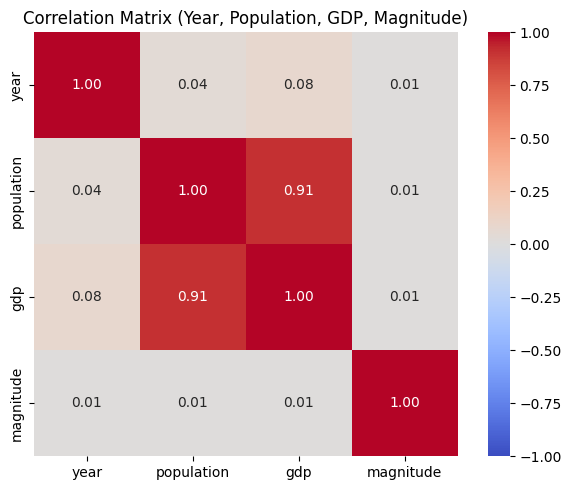

In [15]:
num_cols= ['year','population','gdp','magnitude']
corr = df[num_cols].corr()

plt.figure(figsize=(6.5,5))
sns.heatmap(corr, annot=True, cmap='coolwarm',vmin=-1,vmax=1,fmt='.2f',square=True)
plt.title('Correlation Matrix (Year, Population, GDP, Magnitude)')
plt.tight_layout()
plt.show()

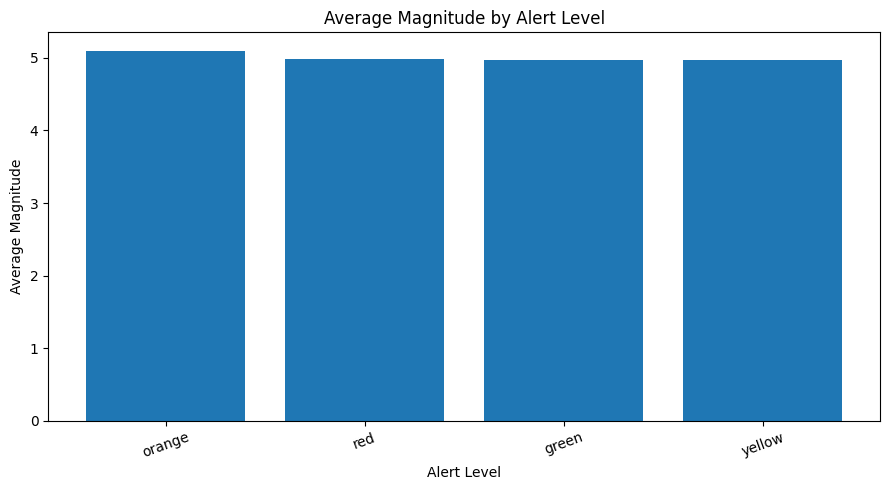

,average_magnitude
alert,
orange,5.10
red,4.99
green,4.97
yellow,4.96


In [17]:
avg_magnitude_by_alert = (
    df.groupby("alert")["magnitude"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
plt.bar(avg_magnitude_by_alert.index, avg_magnitude_by_alert.values)
plt.title("Average Magnitude by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Average Magnitude")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(avg_magnitude_by_alert.to_frame("average_magnitude").round(2))